In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [ ]:
from google.colab import files
upload = files.upload()

In [ ]:
games = pd.read_csv('games.csv')
games.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [ ]:
games = pd.read_csv('games.csv')
games.tail()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
20053,EfqH7VVH,True,1.499791e+12,1.499791e+12,24,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2
20054,WSJDhbPl,True,1.499698e+12,1.499699e+12,82,mate,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2
20055,yrAas0Kj,True,1.499698e+12,1.499698e+12,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3
20056,b0v4tRyF,True,1.499696e+12,1.499697e+12,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4
20057,N8G2JHGG,True,1.499643e+12,1.499644e+12,78,mate,black,10+0,jamboger,1235,ffbob,1339,d4 d5 Bf4 Na6 e3 e6 c3 Nf6 Nf3 Bd7 Nbd2 b5 Bd3...,D00,Queen's Pawn Game: Mason Attack,3


In [ ]:
#untuk mengecek apakah ada missing values
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


In [ ]:
games.isnull().sum()

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [ ]:
#mengetahui banyaknya unique players
#untuk mengetahui banyaknya unique players, maka dapatkan jumlah pemain (player) dari hitam dan putih lalu dijadikan satu

putih_unique = games["white_id"].unique().tolist()
hitam_unique = games["black_id"].unique().tolist()
putih_unique.extend(hitam_unique)

semua_pemain = []
for player in putih_unique:
    if player not in semua_pemain:
        semua_pemain.append(player)

print("Jumlah unique players adalah", len(semua_pemain))

Jumlah unique players adalah 15635


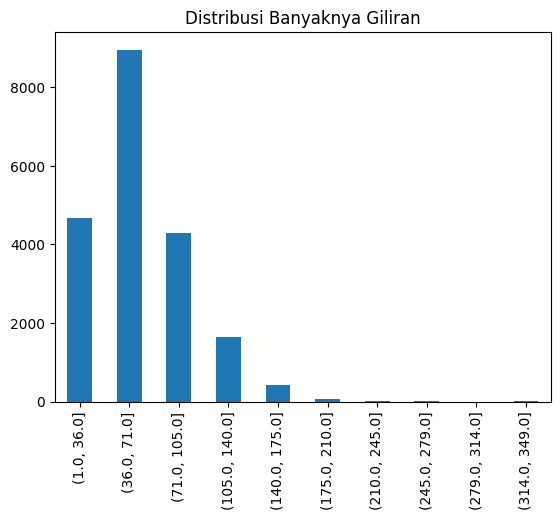

In [ ]:
#distribusi dari banyaknya giliran pemain
ax = pd.cut(games['turns'], 10, precision=0).value_counts().sort_index().plot.bar()
ax_attr = ax.set(title = "Distribusi Banyaknya Giliran")

precision=0 agar angka tidak desimal. Dari histogram di atas dapat dilihat bahwa kebanyakan permainan diakhiri kurang dari 71 gerakan dan hampir semua permainan berakhir sebelum 175 gerakan.

In [ ]:
#dalam catur, rating adalah yang menentukan seberapa skill seorang pemain
#grandmaster catur biasanya memiliki online rating di atas 2500

rating_putih = games["white_rating"].tolist()
rating_hitam = games["black_rating"].tolist()
rating_putih.extend(rating_hitam)

mean_rating, max_rating, min_rating, std_rating = round(np.mean(rating_putih), 2), max(rating_putih), min(rating_putih), round(np.std(rating_putih), 2)
print("Rata-rata Rating:", mean_rating)
print("Max Rating:", max_rating)
print("Min Rating:", min_rating)
print("Std Rating:", std_rating)

Rata-rata Rating: 1592.73
Max Rating: 2723
Min Rating: 784
Std Rating: 291.16


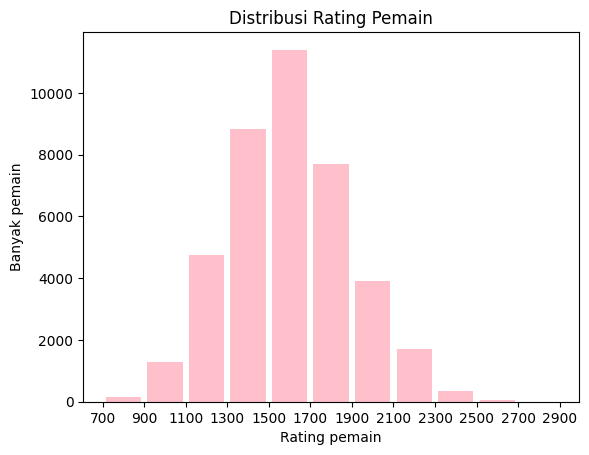

In [ ]:
#distribusi rating pemain. dimulai dari rating 600 sampai 2500+ (grandmaster)
bins = [i for i in range(700, 3000, 200)]
#bins adalah rentang nilai. misal diambil rentang nilai 200 untuk setiap bar
plt.hist(rating_putih, bins, histtype="bar", rwidth=0.85, color="pink")
plt.title("Distribusi Rating Pemain")
plt.xlabel("Rating pemain")
plt.ylabel("Banyak pemain")
plt.xticks(range(700, 3000, 200))
plt.show()

Histogram di atas menunjukkan bahwa ratinng pemain terbanyak ada di rentang 1500 dan 1700.

In [ ]:
#mengkategorikan permainan berdasarkan time increment

games['increment_code']

0         15+2
1         5+10
2         5+10
3         20+0
4         30+3
         ...  
20053    10+10
20054     10+0
20055     10+0
20056     10+0
20057     10+0
Name: increment_code, Length: 20058, dtype: object

In [ ]:
#memisah kolom increment_code menjadi dua kolom yaitu "waktu" dan "increment"
games['game_category'] = games['increment_code'].str.split('+').str[0]
games['increment'] = games['increment_code'].str.split('+').str[1]

#mengganti tipe data menjadi int
games['game_category'] = games['game_category'].astype(int)
games['increment'] = games['increment'].astype(int)

#
games['game_category'][games['game_category'] >= 10] = 11
games['game_category'][games['game_category'] < 3] = 2
games['game_category'][(games['game_category'] >= 3) & (games['game_category'] < 10)] = 5

games['game_category'].replace(11, 'rapid', inplace = True)
games['game_category'].replace(2, 'bullet', inplace = True)
games['game_category'].replace(5, 'blitz', inplace = True)

<ipython-input-13-43ce5d535e8c>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games['game_category'][games['game_category'] >= 10] = 11
<ipython-input-13-43ce5d535e8c>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games['game_category'][games['game_category'] < 3] = 2
<ipython-input-13-43ce5d535e8c>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games['game_category'][(games['game_category'] >= 3) & (games['game_category'] <

In [ ]:
games['game_category'].value_counts()

rapid     15988
blitz      3939
bullet      131
Name: game_category, dtype: int64

In [ ]:
#melihat kemenangan berdasarkan kategori
games['victory_status'].value_counts()

resign       11147
mate          6325
outoftime     1680
draw           906
Name: victory_status, dtype: int64

Text(0.5, 1.0, 'Status Victory vs Jumlah Vicotry')

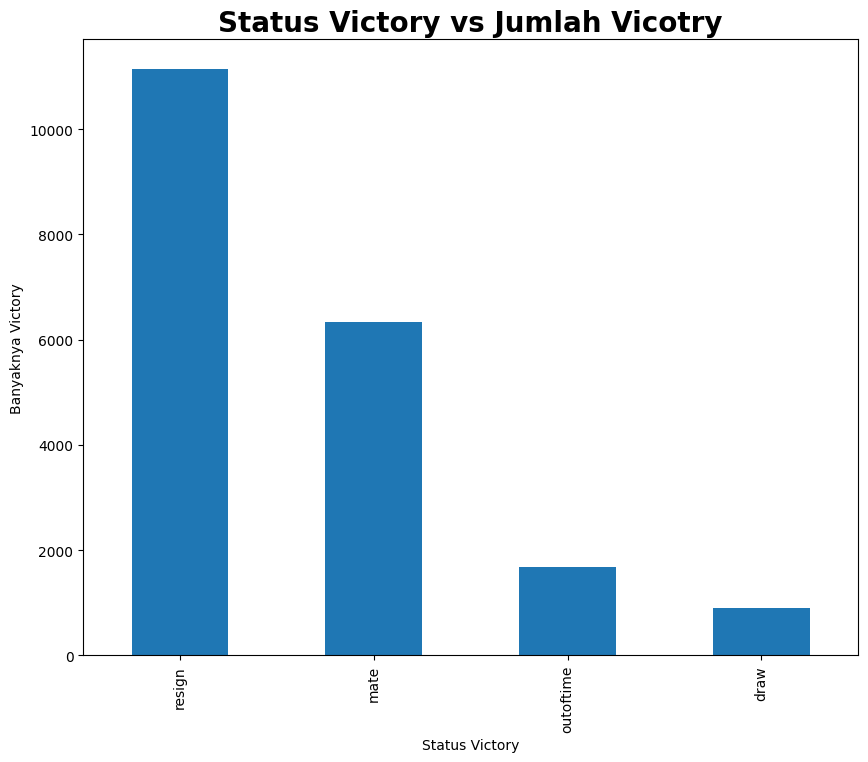

In [ ]:
plt.figure(figsize = (10,8))
ax = games.victory_status.value_counts()[:25].plot(kind = 'bar')
plt.xlabel("Status Victory")
plt.ylabel("Banyaknya Victory")
plt.title("Status Victory vs Jumlah Vicotry",fontsize =20, weight = 'bold')

In [ ]:
games.winner.value_counts()

white    10001
black     9107
draw       950
Name: winner, dtype: int64

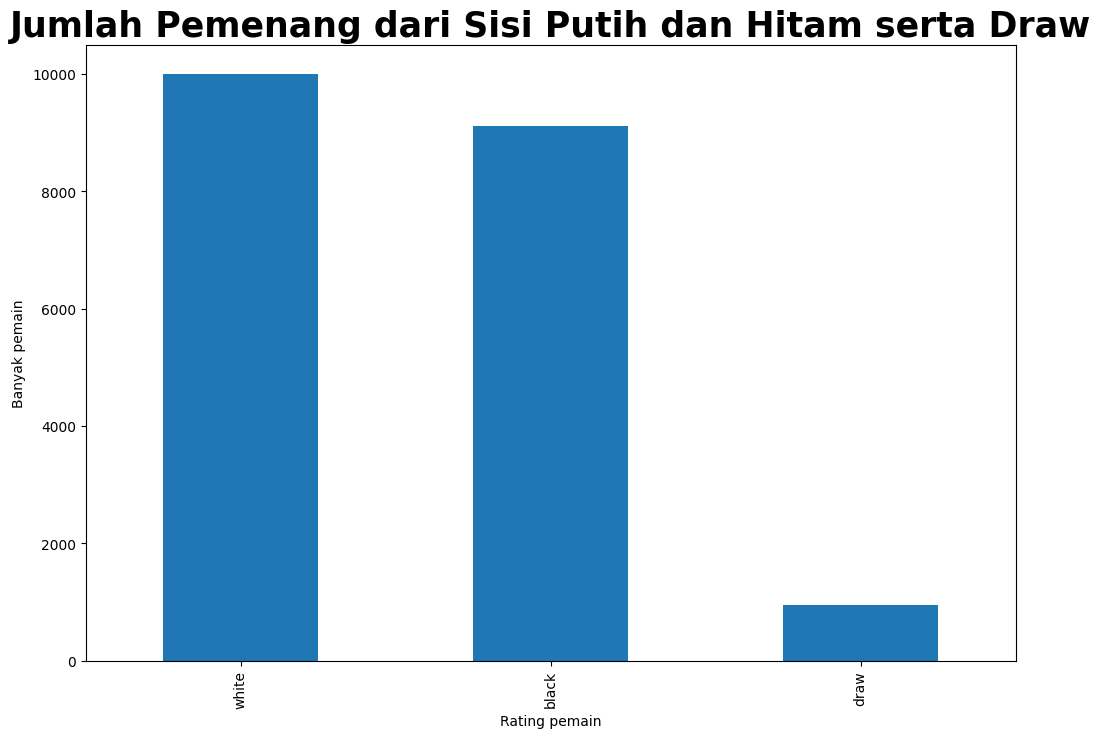

In [ ]:
#melihat jumlah menang dari sisi putih dan hitam serta banyaknya draw
plt.figure(figsize = (12,8))
ax = games.winner.value_counts()[:25].plot(kind = 'bar')
plt.title("Jumlah Pemenang dari Sisi Putih dan Hitam serta Draw", fontsize = 25, weight = 'bold')
plt.xlabel("Rating pemain")
plt.ylabel("Banyak pemain")
plt.show()

Dapat dilihat bahwa alasan permainan berakhir paling banyak karena player melakukan resign/menyerah.

In [ ]:
#melihat banyaknya opening unique
unique_op = games["opening_name"].unique().tolist()
print("Banyaknya opening unique adalah", len(unique_op))


Banyaknya opening unique adalah 1477


In [ ]:
#10 opening paling banyak dimainkan
games['opening_name'].value_counts().head(10)

Van't Kruijs Opening                             368
Sicilian Defense                                 358
Sicilian Defense: Bowdler Attack                 296
Scotch Game                                      271
French Defense: Knight Variation                 271
Scandinavian Defense: Mieses-Kotroc Variation    259
Queen's Pawn Game: Mason Attack                  232
Queen's Pawn Game: Chigorin Variation            229
Scandinavian Defense                             223
Horwitz Defense                                  209
Name: opening_name, dtype: int64

In [ ]:
#3 pemain putih dengan rating tertinggi
top_3_putih = games.nlargest(3, 'white_rating')
top_3_putih[['id' , 'white_id' , 'white_rating']]

,id,white_id,white_rating
13009,Y1oXTO75,justicebot,2700
10147,qIn8fg1t,blitzbullet,2622
904,TPZImYDg,lance5500,2621


In [ ]:
#3 pemain hitam dengan rating tertinggi
top_3_hitam = games.nlargest(3, 'black_rating')
top_3_hitam[['id' , 'black_id' , 'black_rating']]

,id,black_id,black_rating
4473,rAO6oybn,justicebot,2723
5373,zkk33R0Z,lance5500,2621
5374,5gtNuMhB,lance5500,2621


In [ ]:
#top 10 pemain?
#membuat white id dan black id menjadi satu dataframe

gabung = ['white_id', 'white_rating']
playerputih = games[gabung]
playerputih.columns = ['id_pemain', 'rating_pemain']
gabung = ['black_id', 'black_rating']
playerhitam = games[gabung]
playerhitam = playerhitam[gabung]
playerhitam.columns = ['id_pemain', 'rating_pemain']
playergabung = pd.concat([playerputih, playerhitam])

In [ ]:
#menentukan max rating untuk setiap id
ID = []
rating = []
for x in playergabung.id_pemain.unique():
    ID.append(x)
    temp = playergabung[playergabung['id_pemain'] == x]
    rating.append(temp.rating_pemain.max())
playergabung = pd.DataFrame()
playergabung['id_pemain'] = np.array(ID)
playergabung['rating_pemain'] = np.array(rating)

In [ ]:
top10pemain = playergabung.sort_values(by='rating_pemain', ascending=False).head(10)
print(top10pemain)

                 id_pemain  rating_pemain
6531            justicebot           2723
5201           blitzbullet           2622
488              lance5500           2621
11357             avill050           2588
4283   shahoviy_komentator           2586
7741            teatime007           2579
6215             le_truand           2549
15331               tree33           2540
13193             marantz3           2526
5906           king-bullet           2522


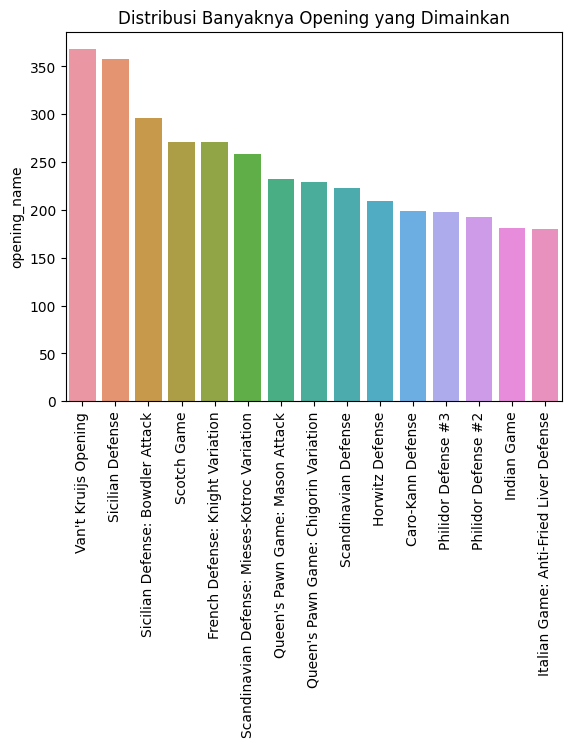

In [ ]:
#15 opening paling banyak dimainkan
opening_dist = games['opening_name'].value_counts()
chart = sns.barplot( x = opening_dist.index[:15], y = opening_dist[:15])
ax_attr = chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
ax_attr = chart.set(title = "Distribusi Banyaknya Opening yang Dimainkan")

<ipython-input-31-aaa4b411f6e1>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  cor = games.corr()


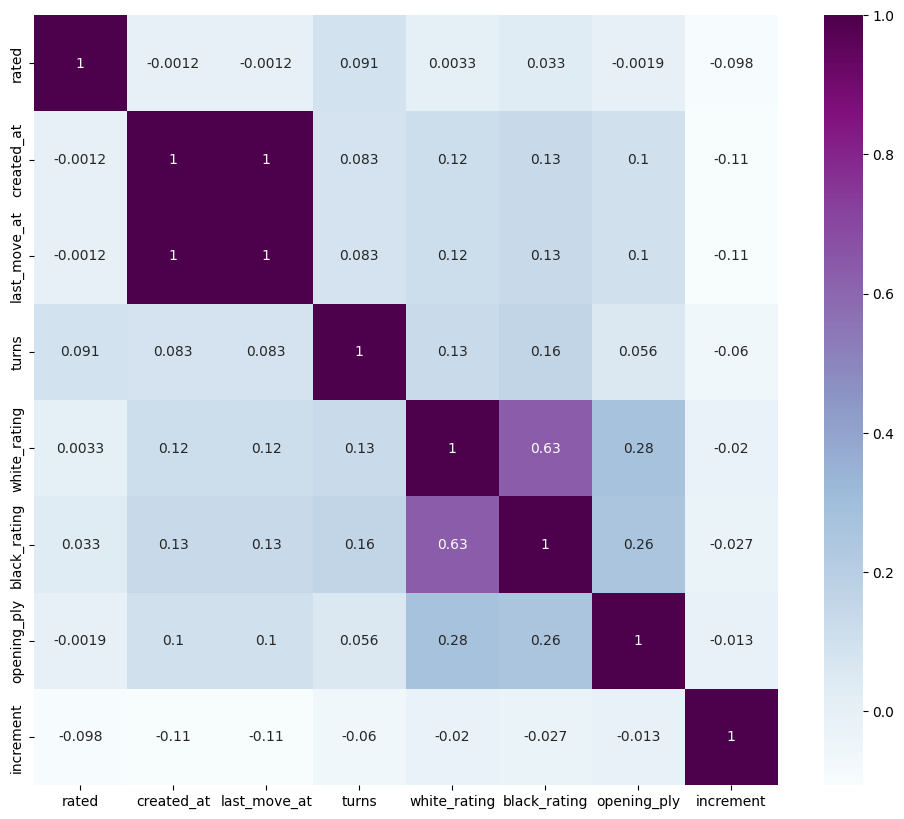

In [ ]:
plt.figure(figsize=(12, 10))
cor = games.corr()
sb.heatmap(cor, annot=True, cmap=plt.cm.BuPu)
plt.show()

<Axes: ylabel='Putih Menang'>

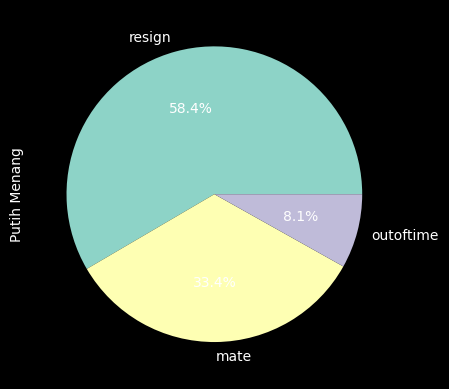

In [ ]:
white = games.loc[games['winner']=='white']
black = games.loc[games['winner']=='black']
white['victory_status'].value_counts().plot.pie(autopct="%.1f%%", label="Putih Menang")

<Axes: ylabel='Hitam Menang'>

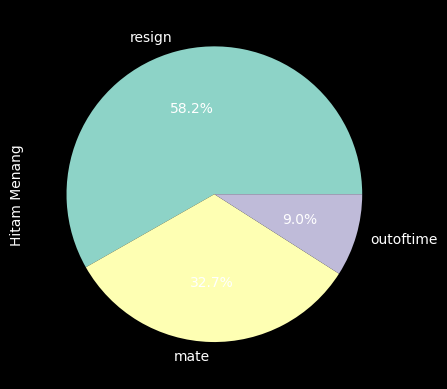

In [ ]:
black['victory_status'].value_counts().plot.pie(autopct="%.1f%%", label="Hitam Menang")

<ipython-input-34-828e33ac8217>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(games.turns,color='red')


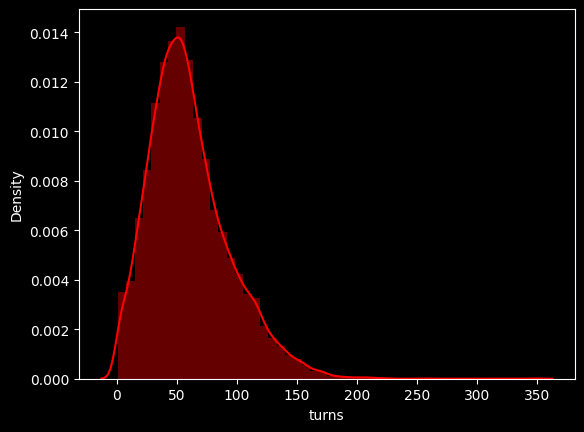

In [ ]:
plt.style.use('dark_background')
sns.distplot(games.turns,color='red')
plt.show()